# MedlinePlus: data understanding

MedlinePlus is the retrieval corpus for the Simplifier. Two files feed it: one health-topic file that holds a plain-language summary per topic, and five glossary files that hold short definitions of clinical terms. This notebook profiles both, flattens them into the retrieval schema, and chunks the text that is too long to embed as one passage.

## Setup

In [1]:
import html
import re
import xml.etree.ElementTree as ET
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

%matplotlib inline
sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 140)
pd.set_option('display.width', 220)

# Walk up from this notebook until the folder holding both data/ and notebooks/ is found.
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / 'data').is_dir() or not (REPO_ROOT / 'notebooks').is_dir():
    if REPO_ROOT == REPO_ROOT.parent:
        raise FileNotFoundError('Run this notebook from inside the repo (see SETUP.md).')
    REPO_ROOT = REPO_ROOT.parent

DATA_DIR = REPO_ROOT / 'data'
MPL_DIR = DATA_DIR / 'medlineplus'
MPL_TOPICS_XML = MPL_DIR / 'health_topics' / 'mplus_topics_2026-09-10.xml'
MPL_DEFINITIONS_DIR = MPL_DIR / 'definitions_of_health_terms'
print('data folder:', DATA_DIR)

data folder: C:\Users\hoang\Subdisk\school\UIC\BTT\Fall AI Studio\Google-2E\data


## Parsing

The topic file is one big XML document; the glossary is five small ones. They share the same idea but not the same shape, so they get two parsers.

The topic summary sits inside a `full-summary` element, HTML-escaped, so it has to be unescaped and stripped of tags before it can be read. Most of the metadata (title, URL, language, date) lives in attributes on the `health-topic` element rather than in child elements.

In [2]:
# Text helpers. XML pretty-printing adds indentation and newlines, and the
# MedlinePlus summaries arrive HTML-escaped, so both have to be cleaned up
# before the text is usable.

_WS = re.compile(r"\s+")
_TAG = re.compile(r"<[^>]+>")


def normalize_ws(value):
    # Collapse the indentation and newlines that XML pretty-printing adds.
    if not value:
        return ""
    return _WS.sub(" ", value).strip()


def strip_html(value):
    # Unescape the HTML entities first, then drop the remaining tags.
    if not value:
        return ""
    return normalize_ws(html.unescape(_TAG.sub(" ", value)))


def word_count(text):
    return len(text.split()) if text else 0


def _n_unique(series):
    # nunique() raises on list-valued cells, so fall back to a sentinel.
    try:
        return int(series.nunique(dropna=True))
    except TypeError:
        return -1


def classify_columns(df, id_columns=None):
    # Sort each column into a rough type so the reader knows what can be a feature.
    id_columns = id_columns or []
    rows = []
    for name in df.columns:
        series = df[name]
        dtype = str(series.dtype)
        is_list = series.map(type).isin([list, dict]).any()
        if name in id_columns:
            kind = "id (join key, never a feature)"
        elif is_list:
            kind = "nominal (multi-value list)"
        elif pd.api.types.is_bool_dtype(series):
            kind = "nominal (binary flag)"
        elif pd.api.types.is_numeric_dtype(series):
            nunique = _n_unique(series)
            is_int = pd.api.types.is_integer_dtype(series)
            if is_int and nunique <= 10 and series.min() >= 0:
                kind = "ordinal or nominal (small integer range)"
            elif is_int:
                kind = "integer"
            else:
                kind = "continuous"
        elif dtype == "object" and _n_unique(series) <= 50:
            kind = "nominal"
        else:
            kind = "nominal (free text)"
        rows.append({
            "column": name,
            "dtype": dtype,
            "course_type": kind,
            "n_unique": _n_unique(series),
            "pct_missing": round(float(series.isna().mean() * 100), 2),
        })
    return pd.DataFrame(rows)


def missingness(df):
    # Count nulls and empty strings separately. This dataset has no nulls, so a
    # plain isna() check would report nothing missing.
    counts = df.isna().sum()
    blank = (df.astype(str) == "").sum()
    return (
        pd.DataFrame({
            "missing": counts,
            "missing_pct": (counts / len(df) * 100).round(2),
            "blank_or_empty": blank,
        })
        .query("missing > 0 or blank_or_empty > 0")
        .sort_values("missing", ascending=False)
    )

In [3]:
# MedlinePlus health topics. One row per health-topic element.

def parse_medlineplus_topics(path=MPL_TOPICS_XML, limit=None):
    root = ET.parse(path).getroot()
    topics = list(root.findall("health-topic"))
    if limit is not None:
        topics = topics[:limit]

    rows = []
    for topic in topics:
        summary = strip_html(topic.findtext("full-summary"))
        groups = [normalize_ws(g.text) for g in topic.findall("group")]
        mesh = [normalize_ws(m.text) for m in topic.findall("mesh-heading/descriptor")]
        sites = topic.findall("site")
        language = topic.get("language", "")
        rows.append({
            "doc_uid": f"medlineplus_topics/{topic.get('id', '')}",
            "source_dataset": "medlineplus_topics",
            "collection": "MedlinePlus Health Topics",
            "topic_id": topic.get("id", ""),
            "title": normalize_ws(topic.get("title")),
            "url": topic.get("url", ""),
            "language": language,
            "is_english": language.lower() == "english",
            "date_created": topic.get("date-created", ""),
            "meta_desc": normalize_ws(topic.get("meta-desc")),
            "also_called": [normalize_ws(a.text) for a in topic.findall("also-called")],
            "text": summary,
            "char_len": len(summary),
            "word_len": word_count(summary),
            "text_missing": summary == "",
            "n_groups": len(groups),
            "groups": groups,
            "n_mesh": len(mesh),
            "mesh": mesh,
            "n_sites": len(sites),
            "primary_institute": normalize_ws(topic.findtext("primary-institute")),
            "n_see_reference": len(topic.findall("see-reference")),
            "other_language": [o.get("vernacular-name", "") for o in topic.findall("other-language")],
        })
    return pd.DataFrame(rows)


# MedlinePlus glossary. One row per term across the five definition files.

def parse_medlineplus_definitions(folder=MPL_DEFINITIONS_DIR):
    rows = []
    for path in sorted(folder.glob("*.xml")):
        root = ET.parse(path).getroot()
        for group in root.findall("term-group"):
            # Every term carries a stray leading '>' from the source export.
            term = normalize_ws(group.findtext("term")).lstrip(">").strip()
            definition = normalize_ws(group.findtext("definition")).lstrip(">").strip()
            rows.append({
                "doc_uid": f"medlineplus_definitions/{path.stem}:{term}",
                "source_dataset": "medlineplus_definitions",
                "collection": path.stem,
                "page_title": root.get("title", ""),
                "title": term,
                "section": "definition",
                "text": definition,
                "url": group.get("reference-url", ""),
                "language": "English",
                "reference": group.get("reference", ""),
                "char_len": len(definition),
                "word_len": word_count(definition),
                "text_missing": definition == "",
            })
    return pd.DataFrame(rows)

## Shape of the two files

In [4]:
# Parse both files and report the basic shape.

topics = parse_medlineplus_topics()
definitions = parse_medlineplus_definitions()

print('topic rows    :', topics.shape[0], '| columns:', topics.shape[1])
print('glossary rows :', definitions.shape[0], '| columns:', definitions.shape[1])
print()

# Every topic is declared once per language. The 'language' attribute is the
# only reliable way to tell the versions apart, so print the split.
print('language attribute:')
print(topics['language'].value_counts().to_string())
print()

print('English topics:', int(topics['is_english'].sum()), 'of', len(topics))

topic rows    : 2033 | columns: 23
glossary rows : 97 | columns: 13

language attribute:
language
English    1017
Spanish    1016

English topics: 1017 of 2033


One topic out of 2,033 is missing its summary. The language split is exactly half: 1,017 English, 1,016 Spanish. MedlinePlus publishes a Spanish translation of every topic, so leaving the filter off would put a translation of a topic next to the English one and let both compete for the same retrieval slot.

## Missing values

In [5]:
# Count nulls and empty strings per column. isna() reports nothing here, so the
# blank_or_empty column is the one to read.

missingness(topics)

,missing,missing_pct,blank_or_empty
meta_desc,0,0.0,1
text,0,0.0,1
primary_institute,0,0.0,414


In [6]:
# The glossary has no missing definitions, but some reference links are empty.

missingness(definitions)

,missing,missing_pct,blank_or_empty
url,0,0.0,33


Only one topic carries an empty summary (Rotator Cuff Injuries), and its URL, topic groups, and 25 links are all present, so it looks like an export gap rather than a removed topic. The glossary has no missing definitions, but 33 of the 97 terms carry no reference URL.

**Drop the empty summary before indexing, and treat an empty glossary reference as "no citation"** A blank reference only matters to the Verifier, which needs a URL to attribute a claim.

## Summary length

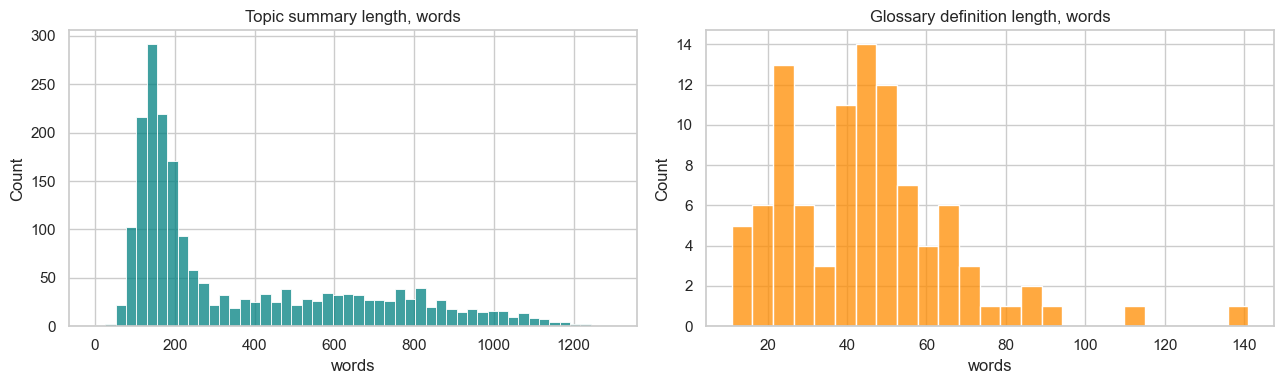

topic summaries:
count    2033.0
mean      362.9
std       289.4
min         0.0
25%       145.0
50%       206.0
75%       575.0
max      1295.0

glossary definitions:
count     97.0
mean      44.7
std       21.7
min       11.0
25%       27.0
50%       46.0
75%       54.0
max      141.0


In [7]:
# How long is a topic summary? The shape decides the chunk size later.

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(topics['word_len'], bins=50, ax=axes[0], color='teal')
axes[0].set_title('Topic summary length, words')
axes[0].set_xlabel('words')

sns.histplot(definitions['word_len'], bins=25, ax=axes[1], color='darkorange')
axes[1].set_title('Glossary definition length, words')
axes[1].set_xlabel('words')

plt.tight_layout()
plt.show()

# The same columns as numbers, so the prose below can be checked.
print('topic summaries:')
print(topics['word_len'].describe().round(1).to_string())
print()
print('glossary definitions:')
print(definitions['word_len'].describe().round(1).to_string())

Topic summaries run long and right-skewed: a median of 206 words, a mean of 363, and a maximum of 1,295. That spread is the reason a single fixed chunk size will not fit every topic, and it is what the chunking section at the bottom works on.

The glossary is the opposite. A median of 46 words and a maximum that still fits inside a prompt, so a definition can be injected whole when the Simplifier needs to explain a term.

## Duplicate glossary terms

In [8]:
# The same term is defined in more than one of the five glossary files, so the
# definition text repeats.
#
# keep=False marks every row in a repeat group, not only the extra copies.

duplicate_definitions = definitions[definitions.duplicated(subset=['text'], keep=False)]
duplicate_definitions = duplicate_definitions.sort_values('text')

print('definition rows                          :', len(definitions))
print('rows whose definition text is not unique :', len(duplicate_definitions))
print()

duplicate_definitions[['collection', 'title', 'word_len']].head(16).to_string(index=False)

definition rows                          : 97
rows whose definition text is not unique : 23



'              collection                               title  word_len\n     vitaminsdefinitions                 Dietary Supplements        47\n    nutritiondefinitions                 Dietary Supplements        47\n     mineralsdefinitions                 Dietary Supplements        47\n     vitaminsdefinitions                        Antioxidants        54\n     mineralsdefinitions                        Antioxidants        54\n      fitnessdefinitions                     Body Mass Index        47\ngeneralhealthdefinitions                     Body Mass Index        47\n    nutritiondefinitions                        Electrolytes        26\n     mineralsdefinitions                        Electrolytes        26\n      fitnessdefinitions                          Heart Rate        40\ngeneralhealthdefinitions                          Heart Rate        40\n     mineralsdefinitions    Multivitamin/Mineral Supplements        50\n     vitaminsdefinitions    Multivitamin/Mineral Supplements   

23 of the 97 glossary rows share their definition text with another row, because a term such as a vitamin appears in more than one of the five files.

**Deduplicate on the definition text before indexing.** Two identical rows in the index take two slots and return the same sentence twice, which crowds out a second definition the Simplifier could have used.

## Column types

In [9]:
# Sort the topic columns into rough types. topic_id is a join key, so it is
# labelled as an identifier rather than being read as a number.

classify_columns(topics, id_columns=['doc_uid', 'topic_id'])

,column,dtype,course_type,n_unique,pct_missing
0,doc_uid,object,"id (join key, never a feature)",2033,0.0
1,source_dataset,object,nominal,1,0.0
2,collection,object,nominal,1,0.0
3,topic_id,object,"id (join key, never a feature)",2033,0.0
4,title,object,nominal (free text),1983,0.0
5,url,object,nominal (free text),2033,0.0
6,language,object,nominal,2,0.0
7,is_english,bool,nominal (binary flag),2,0.0
8,date_created,object,nominal (free text),762,0.0
9,meta_desc,object,nominal (free text),2033,0.0


Three columns decide what happens downstream.

- `topic_id` is an identifier, not a number, even though it looks like one. It labels a row, so it never becomes a feature.
- `language` and `is_english` are the same fact twice, once as text and once as a boolean. Only one is needed once the filter is applied, and the boolean is the cheaper of the two.
- `also_called`, `groups`, `mesh`, and `other_language` are list-valued. They stay as lists because they are context for the Extractor, not retrieval text.

## Flatten into the retrieval schema

The index wants one shape for every document, whether it came from a topic summary or a glossary term. This section builds that shape, because the chunking step and the ChromaDB index both read it.

| Column | Type | Meaning |
| --- | --- | --- |
| `doc_uid` | id | Stable key across both files. Never a feature. |
| `source_dataset` | nominal | `medlineplus_topics` or `medlineplus_definitions`. |
| `collection` | nominal | The topic file or the glossary file name. |
| `title` | text | The topic title, or the glossary term. |
| `section` | nominal | `topic-summary` for topics, `definition` for glossary rows. |
| `text` | text | The retrievable passage. |
| `url` | text | Source link, which is what makes grounding checkable. |
| `language` | nominal | English, kept so a Spanish index can be added later. |
| `char_len`, `word_len` | integer | Length, which drives the chunking decision. |

In [10]:
# The shared retrieval schema. Every document, from either file, lands in these
# ten columns so the index has one shape to read.

RETRIEVAL_COLUMNS = [
    "doc_uid",
    "source_dataset",
    "collection",
    "title",
    "section",
    "text",
    "url",
    "language",
    "char_len",
    "word_len",
]


def to_retrieval_docs_medlineplus(topics_df, definitions_df):
    # Project topic summaries into the schema.
    topic_docs = pd.DataFrame({
        "doc_uid": topics_df["doc_uid"],
        "source_dataset": topics_df["source_dataset"],
        "collection": topics_df["collection"],
        "title": topics_df["title"],
        "section": "topic-summary",
        "text": topics_df["text"],
        "url": topics_df["url"],
        "language": topics_df["language"],
    })

    # Project glossary rows into the same schema, unchanged except for labels.
    definition_docs = pd.DataFrame({
        "doc_uid": definitions_df["doc_uid"],
        "source_dataset": definitions_df["source_dataset"],
        "collection": definitions_df["collection"],
        "title": definitions_df["title"],
        "section": definitions_df["section"],
        "text": definitions_df["text"],
        "url": definitions_df["url"],
        "language": definitions_df["language"],
    })

    # Stack the two and measure the length columns from the text itself.
    out = pd.concat([topic_docs, definition_docs], ignore_index=True, sort=False)
    out["char_len"] = out["text"].str.len()
    out["word_len"] = out["text"].map(word_count)
    return out[RETRIEVAL_COLUMNS]

In [11]:
# Apply the English filter and the empty-summary drop before flattening, so no
# unusable row reaches the schema.

english_topics = topics[topics['is_english']].copy()
english_topics = english_topics[english_topics['text'].str.strip() != ''].copy()

medlineplus_documents = to_retrieval_docs_medlineplus(english_topics, definitions)

# One summary row per source file.
summary = medlineplus_documents.groupby('source_dataset').agg(
    documents=('doc_uid', 'size'),
    unique_documents=('doc_uid', 'nunique'),
    median_words=('word_len', 'median'),
    max_words=('word_len', 'max'),
)

print('total retrieval documents:', f'{len(medlineplus_documents):,}')
print('shared columns:', list(medlineplus_documents.columns))
summary

total retrieval documents: 1,113
shared columns: ['doc_uid', 'source_dataset', 'collection', 'title', 'section', 'text', 'url', 'language', 'char_len', 'word_len']


,documents,unique_documents,median_words,max_words
source_dataset,,,,
medlineplus_definitions,97,97,46.0,141
medlineplus_topics,1016,1016,193.0,1225


In [12]:
# The first few rows, to confirm both sources landed in the same shape.

medlineplus_documents.head(4)

,doc_uid,source_dataset,collection,title,section,text,url,language,char_len,word_len
0,medlineplus_topics/6308,medlineplus_topics,MedlinePlus Health Topics,A1C,topic-summary,"A1C is a blood test for type 2 diabetes and prediabetes . It measures your average blood glucose, or blood sugar , level over the past 3...",https://medlineplus.gov/a1c.html,English,1074,197
1,medlineplus_topics/3061,medlineplus_topics,MedlinePlus Health Topics,Abdominal Pain,topic-summary,"Your abdomen extends from below your chest to your groin. Some people call it the stomach, but your abdomen contains many other importan...",https://medlineplus.gov/abdominalpain.html,English,752,136
2,medlineplus_topics/122,medlineplus_topics,MedlinePlus Health Topics,Abortion,topic-summary,An induced abortion is a procedure to end a pregnancy. It can be done two different ways: Medication abortion (also called medical abort...,https://medlineplus.gov/abortion.html,English,520,89
3,medlineplus_topics/3063,medlineplus_topics,MedlinePlus Health Topics,Abscess,topic-summary,"An abscess is a pocket of pus. You can get an abscess almost anywhere in your body. When an area of your body becomes infected, your bod...",https://medlineplus.gov/abscess.html,English,696,116


The flattening step is what makes the two files interchangeable. Once both sit in the ten columns above, the index code, the retrieval smoke test, and the Simplifier's retrieval tool do not need to know which file a passage came from.

**Keep the `url` and `collection` columns.** They are not decoration. The Verifier has to attribute a claim to a source, and the topic URL is what makes the attribution checkable.

## Chunk before indexing

The length profile sets the target. The median English topic is 193 words, and that median is the width the index should hold, rather than a number picked by hand. Anything longer gets split.

**How the split works.** Whole sentences are packed into a run until the next sentence would push the run past the target, then a new run starts. No sentence is cut in half, because a claim severed from its subject cannot be attributed by the Verifier. A single sentence longer than the target becomes a chunk on its own, and that is the one way a chunk can run past the target.

**Why the last two runs get rebalanced.** Greedy packing leaves a short final run whenever a passage ends just past a target multiple, and a ten-word fragment embeds to almost nothing while still taking a retrieval slot. When the final run falls below half the target, the last two runs are rebalanced into two even halves on a sentence boundary.

**What changes on each chunk.** The key gains a suffix such as `#chunk1`, so no two rows share a `doc_uid`. A document that fits in one chunk keeps its original key. `char_len` and `word_len` are measured again from the chunk, since the earlier values describe text that no longer sits in that row. A document with no text produces no row at all.

In [13]:
# Chunking helpers. Sentences are the unit that is never broken, so the first
# job is a sentence splitter.

# A sentence boundary is a period, question mark, or exclamation mark, followed
# by whitespace, followed by a capital letter or a digit. The lookarounds keep
# the punctuation attached and stop the split landing inside a number.
_SENTENCE_BREAK = re.compile(r"(?<=[.!?])\s+(?=[A-Z0-9])")


def split_into_sentences(text):
    # The rule is simple and has one known failure. "Dr. Smith" reads as a
    # sentence end, which costs a chunk a shorter tail but loses no text.
    cleaned = normalize_ws(text)
    if not cleaned:
        return []
    return [s for s in _SENTENCE_BREAK.split(cleaned) if s]


def _split_in_half(sentences):
    # Cut a run of sentences into two parts of roughly equal word count,
    # landing on a sentence boundary so each part still reads in order.
    total_words = sum(word_count(s) for s in sentences)
    half_words = total_words / 2

    first_half = []
    running_words = 0

    for sentence in sentences:
        # The guard on first_half stops the cut landing at position zero.
        if first_half and running_words + word_count(sentence) > half_words:
            break
        first_half.append(sentence)
        running_words = running_words + word_count(sentence)

    second_half = sentences[len(first_half):]
    return first_half, second_half


def chunk_text(text, target_words=193):
    sentences = split_into_sentences(text)
    if not sentences:
        return []

    # Pack whole sentences until the next one would push the run past the
    # target, then start a new run.
    grouped_sentences = []
    current_sentences = []
    current_words = 0

    for sentence in sentences:
        sentence_words = word_count(sentence)
        # The guard on current_sentences stops a run closing while still empty.
        if current_sentences and current_words + sentence_words > target_words:
            grouped_sentences.append(current_sentences)
            current_sentences = []
            current_words = 0
        current_sentences.append(sentence)
        current_words = current_words + sentence_words

    if current_sentences:
        grouped_sentences.append(current_sentences)

    # Rebalance a thin final run into two even halves.
    min_words = target_words // 2
    tail_words = sum(word_count(s) for s in grouped_sentences[-1])

    if len(grouped_sentences) > 1 and tail_words < min_words:
        merged = grouped_sentences[-2] + grouped_sentences[-1]
        first_half, second_half = _split_in_half(merged)
        grouped_sentences[-2:] = [first_half, second_half]

    return [" ".join(group) for group in grouped_sentences]


def chunk_retrieval_documents(df, target_words=193):
    # Split every long document and keep the keys unique.
    rows = []

    for _, document in df.iterrows():
        # A missing summary arrives as a non-string, so it is treated as empty.
        text = document["text"] if isinstance(document["text"], str) else ""

        pieces = chunk_text(text, target_words=target_words)
        if not pieces:
            continue

        for position, piece in enumerate(pieces, start=1):
            row = document.to_dict()
            # Only a document that actually split needs the chunk number.
            if len(pieces) > 1:
                row["doc_uid"] = f"{document['doc_uid']}#chunk{position}"
            row["text"] = piece
            row["char_len"] = len(piece)
            row["word_len"] = word_count(piece)
            rows.append(row)

    return pd.DataFrame(rows)[RETRIEVAL_COLUMNS]

In [14]:
# Split the corpus at the width the profile chose. One chunk is the unit the
# index embeds, so this is the size that matters.

TARGET_WORDS = 193

medlineplus_chunks = chunk_retrieval_documents(
    medlineplus_documents,
    target_words=TARGET_WORDS,
)

# Count both sides of the split. The chunk count has to be the larger number,
# and the key count has to equal the row count, or two chunks collide in the
# index and one silently replaces the other.
documents_before = len(medlineplus_documents)
chunks_after = len(medlineplus_chunks)
unique_keys_after = medlineplus_chunks['doc_uid'].nunique()

# Take the "#chunk" suffix off, so a split document still counts once.
source_keys = medlineplus_chunks['doc_uid'].str.split('#').str[0]
documents_with_text = source_keys.nunique()

# Which rows are second or later chunks.
is_split_chunk = medlineplus_chunks['doc_uid'].str.contains('#chunk')
documents_split = source_keys[is_split_chunk].nunique()

print('target width (words)       :', TARGET_WORDS)
print('documents before chunking  :', f'{documents_before:,}')
print('documents that split       :', f'{documents_split:,}')
print('chunks after chunking      :', f'{chunks_after:,}')
print('unique keys after chunking :', f'{unique_keys_after:,}')
print('every key unique           :', unique_keys_after == chunks_after)
print()

# Sizes per chunk. The minimum is the check that matters most, because a
# fragment of a few words embeds to almost nothing and still takes a slot.
chunk_summary = medlineplus_chunks.groupby('source_dataset').agg(
    chunks=('doc_uid', 'size'),
    median_words=('word_len', 'median'),
    min_words=('word_len', 'min'),
    max_words=('word_len', 'max'),
)
chunk_summary

target width (words)       : 193
documents before chunking  : 1,113
documents that split       : 502
chunks after chunking      : 2,403
unique keys after chunking : 2,403
every key unique           : True



,chunks,median_words,min_words,max_words
source_dataset,,,,
medlineplus_definitions,97,46.0,11,141
medlineplus_topics,2306,159.0,33,217


In [15]:
# Write the chunked corpus to disk. The index reads this file next.
#
# The filename carries 'chunked' so it is not confused with the flat schema
# frame built above: this file holds the 2,403 split passages, not the 1,113
# documents the flattening step produced.
#
# force_ascii=False keeps accented characters as characters instead of escapes.

output_path = DATA_DIR / 'retrieval_docs_medlineplus_chunked.jsonl'

medlineplus_chunks.to_json(
    output_path,
    orient='records',
    lines=True,
    force_ascii=False,
)

size_mb = output_path.stat().st_size / 1e6
print(f'wrote {len(medlineplus_chunks):,} chunks to {output_path} ({size_mb:.1f} MB)')

wrote 2,403 chunks to C:\Users\hoang\Subdisk\school\UIC\BTT\Fall AI Studio\Google-2E\data\retrieval_docs_medlineplus_chunked.jsonl (2.8 MB)


## Sample topics

In [16]:
# Counts hide how the text is written, so print a few real summaries and read them.
# These are drawn from english_topics, the same filtered frame the index reads, so
# nothing Spanish can appear here.

for i, sample in enumerate(english_topics['text'].sample(3, random_state=42)):
    print(f'--- SAMPLE {i+1} ---')
    print(sample[:500])
    print()

--- SAMPLE 1 ---
Taking home a new baby is one of the happiest times in a woman's life. But it also presents both physical and emotional challenges. : Get as much rest as possible. You may find that all you can do is eat, sleep, and care for your baby. And that is perfectly okay. You will have spotting or bleeding, like a menstrual period, off and on for up to six weeks. You might also have swelling in your legs and feet, feel constipated, have menstrual-like cramping. Even if you are not breastfeeding, you can 

--- SAMPLE 2 ---
Nearly everyone has had indigestion at one time. It's a feeling of discomfort or a burning feeling in your upper abdomen. You may have heartburn or belch and feel bloated. You may also feel nauseated, or even throw up. You might get indigestion from eating too much or too fast, eating high-fat foods, or eating when you're stressed. Smoking, drinking too much alcohol, using some medicines, being tired, and having ongoing stress can also cause indigestion or mak

In [17]:
# The glossary is what the Simplifier injects when a term needs explaining.
# Print a few definitions to see the register.

for i, sample in enumerate(definitions['text'].sample(3, random_state=42)):
    print(f'--- DEFINITION {i+1} ---')
    print(sample[:300])
    print()

--- DEFINITION 1 ---
Fiber is a substance in plants. Dietary fiber is the kind you eat. It's a type of carbohydrate. You may also see it listed on a food label as soluble fiber or insoluble fiber. Both types have important health benefits. Fiber makes you feel full faster, and stay full for a longer time. That can help 

--- DEFINITION 2 ---
Iron is a mineral. It is also added to some food products and is available as a dietary supplement. Iron is a part of hemoglobin, a protein that transports oxygen from the lungs to the tissues. It helps provide oxygen to muscles. Iron is important for cell growth, development, and normal body functi

--- DEFINITION 3 ---
Vitamin E is an antioxidant. It plays a role in your immune system and metabolic processes. Most people get enough vitamin E from the foods they eat. Good sources of vitamin E include vegetable oils, margarine, nuts and seeds, and leafy greens. Vitamin E is added to foods like cereals. It is also av



The topic summaries are already written in plain language, which is why MedlinePlus is the retrieval base rather than MedQuAD. A summary explains a condition in patient-facing sentences at roughly an eighth-grade level, so the Simplifier has grounding text that does not need to be simplified before it is useful.

The glossary definitions run short and definitional ("A condition in which..."), which makes them safe to paste into a prompt without displacing the clinical note the pipeline is rewriting.

**Treat the glossary as substitution material, not as a source of new claims.** A definition explains a term; it does not assert anything about the patient.

## Data profile summary

**Shape.** 2,033 health topics and 97 glossary terms across five files. Half the topics are Spanish translations, so the English filter leaves 1,016. One topic has an empty summary.

**Column types.** Keys: `doc_uid`, `topic_id`. Nominal: `source_dataset`, `collection`, `language`, `section`, `primary_institute`. Binary: `is_english`, `text_missing`. Free text: `title`, `text`, `url`, `meta_desc`. Multi-value lists: `also_called`, `groups`, `mesh`, `other_language`. Integer: `char_len`, `word_len`, `n_groups`, `n_mesh`, `n_sites`, `n_see_reference`.

**Missingness.** No nulls at all, and one empty summary. 33 of 97 glossary rows carry no reference URL. Empty strings are the real blanks, so a plain `isna()` check reports nothing.

**Length.** Topic summaries are right-skewed: median 206 words, mean 363, maximum 1,295. Glossary definitions are short and tight: median 46 words.

**Duplicates.** 23 of 97 glossary rows repeat a definition that appears in another file. The topic side has no exact text repeats.

**Balance and outliers.** Not applicable. There is no label, so there is no class to be imbalanced, and the long summaries are the content to keep rather than outliers to drop. They get chunked instead.

## Decisions before indexing

1. Filter to English topics on the `language` attribute. That removes half the file, all of it translations of topics already held in English.
2. Drop the single topic with an empty summary. Its URL, groups, and links are present, so it is an export gap rather than a removed topic.
3. Deduplicate the glossary on definition text before embedding, so 23 repeated rows do not take two slots each.
4. Chunk every passage longer than 193 words, the median English topic width, on sentence boundaries, and renumber the keys with a `#chunk` suffix.
5. Keep `url` and `collection` on every row, because the Verifier needs a source to attribute a claim to.
6. Write the chunked corpus to `data/retrieval_docs_medlineplus_chunked.jsonl` as the input to the ChromaDB index.